# Лабораторная работа

## Вариант 1.2

Найти экстремум функции:

$$f(x) = (x_1^3 - x_2)^2 + x_2^2 \;\longrightarrow\; \mathrm{extr}$$

на множестве допустимых решений $X \subset \mathbb{R}^2$, заданном ограничениями-неравенствами:

$$g_1(x) = x_1^2 + x_2^2 - 1 \leq 0$$

$$g_2(x) = -x_1 \leq 0$$

Допустимое множество $X$ — правая часть единичного круга $\{x \in \mathbb{R}^2 : x_1 \geq 0,\; x_1^2 + x_2^2 \leq 1\}$.

## 0. Импорт библиотек

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon as MplPolygon
from scipy.optimize import minimize
import sympy as sp
from IPython.display import display, Math

sp.init_printing(use_latex='mathjax')

## Шаг 1. Функция Лагранжа

**Определение.** *Классической функцией Лагранжа* называется:
$$L(x, \lambda) = f(x) + \sum_{j=1}^{p} \lambda_j g_j(x)$$

Для данной задачи (все ограничения — неравенства):

$$\boxed{L(x, \lambda) = (x_1^3 - x_2)^2 + x_2^2 + \lambda_1(x_1^2 + x_2^2 - 1) + \lambda_2(-x_1)}$$

In [2]:
x1, x2, l1, l2 = sp.symbols('x_1 x_2 lambda_1 lambda_2', real=True)

f = (x1**3 - x2)**2 + x2**2
g1 = x1**2 + x2**2 - 1
g2 = -x1

L = f + l1*g1 + l2*g2

print("f(x) ="); display(f)
print("g1(x) ="); display(g1)
print("g2(x) ="); display(g2)
print("L(x, λ) ="); display(sp.expand(L))

f(x) =


                2
  2   ⎛  3     ⎞ 
x₂  + ⎝x₁  - x₂⎠ 

g1(x) =


  2     2    
x₁  + x₂  - 1

g2(x) =


-x₁

L(x, λ) =


     2        2                  6       3          2
λ₁⋅x₁  + λ₁⋅x₂  - λ₁ - λ₂⋅x₁ + x₁  - 2⋅x₁ ⋅x₂ + 2⋅x₂ 

## Шаг 2. Необходимые условия ККТ первого порядка

Пусть $x^e$ — точка локального экстремума. Тогда существуют числа $\lambda^e_1, \lambda^e_2$, такие что:

**А) Условие стационарности:**
$$\frac{\partial L(x^e, \lambda^e)}{\partial x_i} = 0, \quad i = 1, 2$$

**Б) Условие допустимости:**
$$g_1(x^e) \leq 0, \quad g_2(x^e) \leq 0$$

**В) Условие неотрицательности (для минимума) / неположительности (для максимума):**
$$\lambda_j^e \geq 0 \text{ (мин)}, \quad \lambda_j^e \leq 0 \text{ (макс)}, \quad j = 1, 2$$

**Г) Условие дополняющей нежёсткости:**
$$\lambda_j^e \cdot g_j(x^e) = 0, \quad j = 1, 2$$

In [3]:
# Вычислим частные производные функции Лагранжа
dL_x1 = sp.diff(L, x1)
dL_x2 = sp.diff(L, x2)

print("∂L/∂x₁ ="); display(sp.factor(dL_x1))
print("∂L/∂x₂ ="); display(sp.expand(dL_x2))

∂L/∂x₁ =


                   5       2   
2⋅λ₁⋅x₁ - λ₂ + 6⋅x₁  - 6⋅x₁ ⋅x₂

∂L/∂x₂ =


              3       
2⋅λ₁⋅x₂ - 2⋅x₁  + 4⋅x₂

## Шаг 3. Матрица Гессе функции Лагранжа

Для проверки достаточных условий второго порядка вычислим матрицу вторых производных:

$$H_L = \begin{pmatrix} \dfrac{\partial^2 L}{\partial x_1^2} & \dfrac{\partial^2 L}{\partial x_1 \partial x_2} \\[10pt] \dfrac{\partial^2 L}{\partial x_2 \partial x_1} & \dfrac{\partial^2 L}{\partial x_2^2} \end{pmatrix}$$

In [4]:
H = sp.Matrix([
    [sp.diff(L, x1, x1), sp.diff(L, x1, x2)],
    [sp.diff(L, x2, x1), sp.diff(L, x2, x2)]
])

print("H_L =")
display(H)

H_L =


⎡  ⎛         4        ⎛  3     ⎞⎞         2  ⎤
⎢2⋅⎝λ₁ + 9⋅x₁  + 6⋅x₁⋅⎝x₁  - x₂⎠⎠    -6⋅x₁   ⎥
⎢                                            ⎥
⎢                  2                         ⎥
⎣             -6⋅x₁                2⋅(λ₁ + 2)⎦

## Шаг 4. Решение системы ККТ: анализ по случаям

Рассматриваем все возможные комбинации активных и неактивных ограничений.

---

### Случай A: $\lambda_1 = 0,\; \lambda_2 = 0$ (оба ограничения неактивны)

Условия стационарности:
$$\frac{\partial L}{\partial x_1} = 6x_1^2(x_1^3 - x_2) = 0 \implies x_1 = 0 \;\text{ или }\; x_1^3 = x_2$$

$$\frac{\partial L}{\partial x_2} = -2(x_1^3 - x_2) + 4x_2 = 0 \implies x_1^3 = 2x_2$$

Решение: $x_1 = 0; x_2 = 0$.

**Точка:** $x^* = (0,\, 0)$, $f(0,0) = 0$.

Проверка: $g_1(0,0) = -1 < 0$; $g_2(0,0) = 0$.

$\lambda_1 = 0 \geq 0$, $\lambda_2 = 0 \geq 0$ ($f(x) \geq 0$ и $f(0,0) = 0$) → **глобальный минимум**.

---

### Случай B: $\lambda_1 = 0,\; \lambda_2 > 0$ (активно $g_2$: $x_1 = 0$)

Подставляем $\lambda_1 = 0, x_1 = 0$ в $\frac{\partial L}{\partial x_1}$: $-\lambda_2 = 0 \Rightarrow \lambda_2 = 0$. **Противоречие.** Решений нет.

---

### Случай C: $\lambda_1 \neq 0,\; \lambda_2 = 0$ (активно $g_1$: $x_1^2 + x_2^2 = 1$, $x_1 > 0$)

Из условий стационарности при $\lambda_2=0$, $x_1 > 0$:
$$\frac{\partial L}{\partial x_1} = 0 \implies \lambda_1 = -3x_1(x_1^3 - x_2)$$
$$\frac{\partial L}{\partial x_2} = 0 \implies (2\lambda_1 + 4)x_2 = 2x_1^3$$

Решаем с помощью SciPy.

Результат: точка $\approx(0.881,\, 0.473)$ при $\lambda_1\approx-0.556$, $f\approx0.268$.
Знак $\lambda_1 < 0$ допустим для максимума. Однако проверка достаточных условий (шаг 5) покажет: $d^2L > 0$ вдоль допустимого направления — **не является экстремумом**.

---

### Случай D: $g_1$ и $g_2$ активны: $x_1 = 0,\; x_2 = \pm 1$

Из условий стационарности: $\lambda_2 = 0$, $\lambda_1 = -2 \leq 0$ → **глобальные максимумы**.

In [5]:
from scipy.optimize import fsolve
import numpy as np

def kkt_system(vars):
    x1v, x2v, l1v = vars
    eq1 = 2*l1v*x1v + 6*x1v**2*(x1v**3 - x2v)
    eq2 = 2*l1v*x2v - 2*x1v**3 + 4*x2v
    eq3 = x1v**2 + x2v**2 - 1
    return [eq1, eq2, eq3]

sol = fsolve(kkt_system, [0.88, 0.47, -0.55], full_output=True)
x1_arc, x2_arc, l1_arc = sol[0]

def f_val(a, b):
    return (a**3 - b)**2 + b**2

f_arc = f_val(x1_arc, x2_arc)

subs_arc = {x1: x1_arc, x2: x2_arc, l1: l1_arc, l2: 0}
dL1_check = float(dL_x1.subs(subs_arc))
dL2_check = float(dL_x2.subs(subs_arc))
g1_check  = x1_arc**2 + x2_arc**2 - 1

print('Случай C:')
print(f'  x* = ({x1_arc:.6f}, {x2_arc:.6f}), lambda_1 = {l1_arc:.6f}, f = {f_arc:.6f}')
print()
print('Проверка условий:')
print(f'  dL/dx1 = {dL1_check:.2e}')
print(f'  dL/dx2 = {dL2_check:.2e}')
print(f'  g1 = {g1_check:.2e}')
print(f'  lambda_1 = {l1_arc:.4f} (< 0, допустимо для максимума)')
print()
print('Достаточные условия 2-го порядка проверяются на шаге 5.')

Случай C:
  x* = (0.880904, 0.473295), lambda_1 = -0.555710, f = 0.268226

Проверка условий:
  dL/dx1 = -3.29e-13
  dL/dx2 = 1.20e-13
  g1 = 3.56e-13
  lambda_1 = -0.5557 (< 0, допустимо для максимума)

Достаточные условия 2-го порядка проверяются на шаге 5.


## Шаг 5. Достаточные условия экстремума: два способа

Для каждой стационарной точки применяем два способа проверки.

---

### Способ 1. Достаточные условия первого порядка

Обозначим $l$ — число активных ограничений в точке $x^e$, $n=2$ — размерность.

- Если $l = n$ **и** все $\lambda_j < 0$ для активных $j$ → **локальный максимум**.
- Если $l = n$ **и** все $\lambda_j > 0$ для активных $j$ → **локальный минимум**.
- Иначе (условие неокончательно) → переходим к **Способу 2**.

---

### Способ 2. Достаточные и необходимые условия второго порядка

Вычисляем $d^2L(x^e, \lambda^e)$ для **допустимых** $dx \neq 0$, удовлетворяющих:
$$dg_j(x^e)=0, \; j\in J_a,\; \lambda_j\neq 0; \qquad dg_j(x^e)\leq 0, \; j\in J_a,\; \lambda_j=0.$$

- **Необходимое условие минимума:** $d^2L \geq 0$ для всех допустимых $dx$.
- **Достаточное условие минимума:** $d^2L > 0$ для всех ненулевых допустимых $dx$.
- **Необходимое условие максимума:** $d^2L \leq 0$.
- **Достаточное условие максимума:** $d^2L < 0$ для всех ненулевых допустимых $dx$.

---

**Точка P₁ = (0, 0):** $\lambda_1 = 0$, $\lambda_2 = 0$

Активно $g_2$ (с $\lambda_2=0$). *Способ 1*: $l=1 < 2$ → результат неокончателен.

*Способ 2*: допустимые $dx$: $dg_2 = -dx_1 \leq 0 \Rightarrow dx_1 \geq 0$, $dx_2$ — любое.
$$d^2L = 4\,dx_2^2$$
Необходимое условие мин: $d^2L \geq 0$ ✓; достаточное: $d^2L > 0$ при $dx_2 \neq 0$ ✓; при $dx_2=0$: $f(x_1,0)=x_1^6 \geq 0 = f(0,0)$ ✓ → **глобальный минимум**.

---

**Точки P₂ = (0, 1) и P₃ = (0, -1):** $\lambda_1 = -2$, $\lambda_2 = 0$

Активны $g_1$ (с $\lambda_1=-2$) и $g_2$ (с $\lambda_2=0$). *Способ 1*: $l=2=n$, но $\lambda_2=0$ не удовлетворяет $\lambda_j < 0$ → результат неокончателен.

*Способ 2*: $dg_1=0 \Rightarrow dx_2=0$; $dg_2\leq 0 \Rightarrow dx_1\geq 0$.
$$d^2L = H_{11}\,dx_1^2 = -4\,dx_1^2$$
Необходимое условие макс: $d^2L \leq 0$ ✓; достаточное: $d^2L < 0$ при $dx_1 > 0$ ✓ → **глобальный максимум**.

---

**Точка $\approx(0.881, 0.473)$:** $\lambda_1 \approx -0.556$, $\lambda_2 = 0$

*Способ 1*: $l=1 < n=2$ → результат неокончателен.
*Способ 2*: $dg_1=0$ → касательное направление к дуге. Знак $d^2L$ проверяем в коде.

In [6]:
def hessian_L(x1v, x2v, l1v):
    h11 = 12*x1v*(x1v**3 - x2v) + 18*x1v**4 + 2*l1v
    h12 = -6*x1v**2
    h22 = 4 + 2*l1v
    return [[h11, h12], [h12, h22]]

def d2L_on_arc(H, x1v, x2v):
    import math
    norm = math.hypot(x1v, x2v)
    dx1, dx2 = -x2v/norm, x1v/norm   
    return H[0][0]*dx1**2 + 2*H[0][1]*dx1*dx2 + H[1][1]*dx2**2


configs = [
    ('P1=(0,0)', 0, 0, 0, 'мин'),
    ('P2=(0,1)', 0, 1, -2, 'макс'),
    ('P3=(0,-1)', 0, -1, -2, 'макс'),
    ('P4≈(0.881,0.473)', x1_arc, x2_arc, l1_arc, '?'),
]

sep2 = '-' * 107
print(f"{'Точка':<27} {'H11':>7} {'H12':>7} {'H22':>7}   {'d2L':>22}   Необх.  Дост.   Вывод")
print(sep2)
for name, x1v, x2v, l1v, etype in configs:
    H = hessian_L(x1v, x2v, l1v)
    if name.startswith('P1'):
        d2L_str = '4*dx2^2 >= 0'
        nec, suf = '≥ 0', '> 0'
        verdict = 'мин'
    elif name in ('P2=(0,1)', 'P3=(0,-1)'):
        d2L_str = f'{H[0][0]:.1f}*dx1^2 <= 0'
        nec, suf = '≤ 0', '< 0'
        verdict = 'макс'
    else:
        val = d2L_on_arc(H, x1v, x2v)
        d2L_str = f'{val:.4f} > 0'
        nec, suf = 'не ≤ 0', 'не < 0'
        verdict = 'не экстремум'
    print(f'{name:<27} {H[0][0]:>7.3f} {H[0][1]:>7.3f} {H[1][1]:>7.3f}   {d2L_str:>22}   {nec:<7} {suf:<7} {verdict}')
print(sep2)

Точка                           H11     H12     H22                      d2L   Необх.  Дост.   Вывод
-----------------------------------------------------------------------------------------------------------
P1=(0,0)                      0.000   0.000   4.000             4*dx2^2 >= 0   ≥ 0     > 0     мин
P2=(0,1)                     -4.000   0.000   0.000          -4.0*dx1^2 <= 0   ≤ 0     < 0     макс
P3=(0,-1)                    -4.000   0.000   0.000          -4.0*dx1^2 <= 0   ≤ 0     < 0     макс
P4≈(0.881,0.473)             11.950  -4.656   2.889               8.8009 > 0   не ≤ 0  не < 0  не экстремум
-----------------------------------------------------------------------------------------------------------


## Шаг 6. Проверка (scipy.optimize)

In [7]:
def f_num(x):
    return (x[0]**3 - x[1])**2 + x[1]**2

constraints = [
    {'type': 'ineq', 'fun': lambda x:  1 - x[0]**2 - x[1]**2},
    {'type': 'ineq', 'fun': lambda x:  x[0]},
]

res_min = minimize(f_num, [0.0, 0.0], method='SLSQP', constraints=constraints,
                   options={'ftol': 1e-14})
print("Минимум:")
print(f"  x* = ({abs(res_min.x[0]):.6f}, {abs(res_min.x[1]):.6f})")
print(f"  f* = {res_min.fun:.2e}")

print("\nМаксимумы:")
starts = [
    [0.01, 0.98],   
    [0.01, -0.98], 
    [0.50,  0.86],  
    [0.70, -0.71],  
    [0.98,  0.01],  
]
seen = []
for s in starts:
    r = minimize(lambda x: -f_num(x), s, method='SLSQP', constraints=constraints,
                 options={'ftol': 1e-14})
    xr = r.x
    fr = -r.fun
    new = all(np.linalg.norm(xr - xs) > 1e-4 for xs in seen)
    if new:
        seen.append(xr.copy())
        a,b = (0.0 if abs(v)<1e-6 else v for v in xr[:2])
        print(f"  x* = ({a:.5f}, {b:.5f}),  f* = {fr:.6f}")

Минимум:
  x* = (0.000000, 0.000000)
  f* = 0.00e+00

Максимумы:
  x* = (0.00000, 1.00000),  f* = 2.000000
  x* = (0.00000, -1.00000),  f* = 2.000000


## Шаг 7. Сводная таблица

In [8]:
rows = [
    ('P1=(0,0)',  0.0,  0.0,  0.0,  0,  0.0,  'g2',     'глобальный мин'),
    ('P2=(0,1)',  0.0,  1.0, -2.0,  0,  2.0,  'g1, g2', 'глобальный макс'),
    ('P3=(0,-1)', 0.0, -1.0, -2.0,  0,  2.0,  'g1, g2', 'глобальный макс'),
]

sep = '-' * 82
hdr = f"{'Точка':<14} {'x1':>8} {'x2':>8} {'lam1':>7} {'lam2':>5} {'f(x*)':>8}  {'Актив. g':<8}  Тип"
print(hdr)
print(sep)
for name, x1v, x2v, l1v, l2v, fv, ag, tp in rows:
    print(f'{name:<14} {x1v:>8.5f} {x2v:>8.5f} {l1v:>7.4f} {l2v:>5} {fv:>8.5f}  {ag:<8}  {tp}')
print(sep)

Точка                x1       x2    lam1  lam2    f(x*)  Актив. g  Тип
----------------------------------------------------------------------------------
P1=(0,0)        0.00000  0.00000  0.0000     0  0.00000  g2        глобальный мин
P2=(0,1)        0.00000  1.00000 -2.0000     0  2.00000  g1, g2    глобальный макс
P3=(0,-1)       0.00000 -1.00000 -2.0000     0  2.00000  g1, g2    глобальный макс
----------------------------------------------------------------------------------


## Шаг 8. Графическое представление

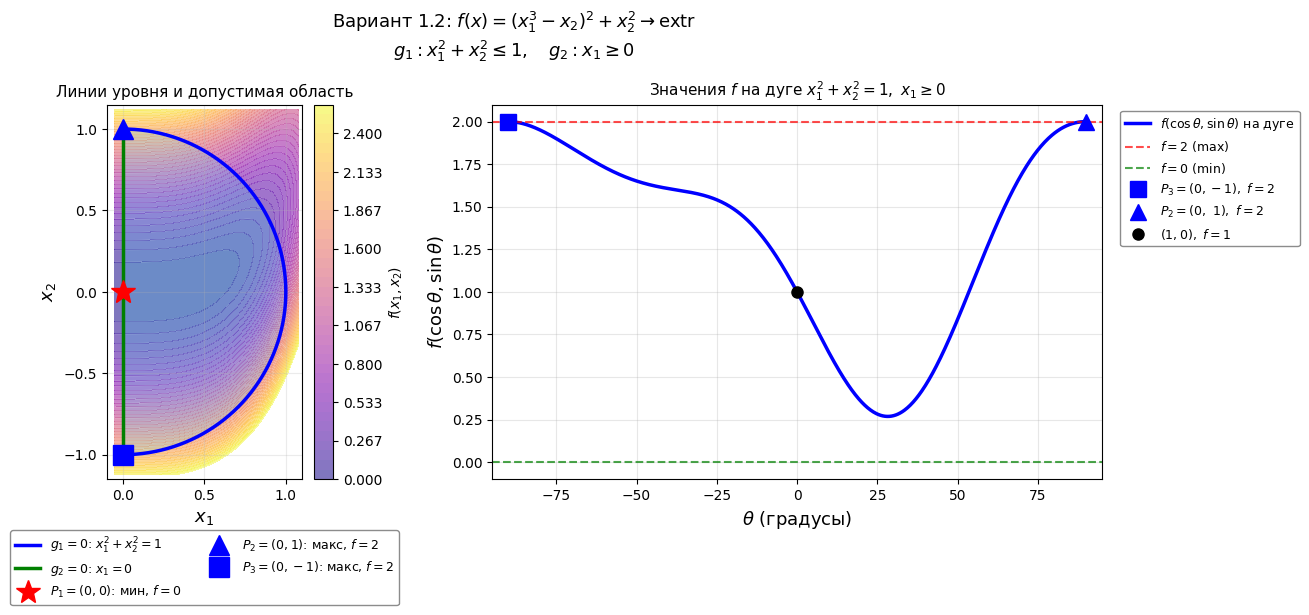

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(
    r"Вариант 1.2: $f(x)=(x_1^3-x_2)^2+x_2^2 \to \mathrm{extr}$"
    "\n"
    r"$g_1: x_1^2+x_2^2\leq1,\quad g_2: x_1\geq0$",
    fontsize=13
)


ax1 = axes[0]

x1g = np.linspace(-0.05, 1.08, 500)
x2g = np.linspace(-1.12, 1.12, 500)
X1, X2 = np.meshgrid(x1g, x2g)
F = (X1**3 - X2)**2 + X2**2

levels = np.linspace(0, 2.6, 40)
cp = ax1.contourf(X1, X2, F, levels=levels, cmap='plasma', alpha=0.55)
plt.colorbar(cp, ax=ax1, label=r'$f(x_1,x_2)$', fraction=0.04, pad=0.02)
ax1.contour(X1, X2, F, levels=levels, colors='white', alpha=0.3, linewidths=0.5)

theta = np.linspace(-np.pi/2, np.pi/2, 400)
ax1.plot(np.cos(theta), np.sin(theta), 'b-', lw=2.5, label=r'$g_1=0$: $x_1^2+x_2^2=1$')
ax1.plot([0, 0], [-1, 1], 'g-', lw=2.5, label=r'$g_2=0$: $x_1=0$')

from matplotlib.patches import Polygon as MplPolygon
verts = np.column_stack([np.cos(theta), np.sin(theta)])
verts = np.vstack([[0, -1], verts, [0, 1]])
poly = MplPolygon(verts, closed=True, alpha=0.15, color='cyan')
ax1.add_patch(poly)

ax1.plot(0, 0,  'r*', ms=18, zorder=7, label=r'$P_1=(0,0)$: мин, $f=0$')
ax1.plot(0, 1,  'b^', ms=14, zorder=7, label=r'$P_2=(0,1)$: макс, $f=2$')
ax1.plot(0, -1, 'bs', ms=14, zorder=7, label=r'$P_3=(0,-1)$: макс, $f=2$')

ax1.set_xlim(-0.1, 1.1);  ax1.set_ylim(-1.15, 1.15)
ax1.set_xlabel(r'$x_1$', fontsize=13);  ax1.set_ylabel(r'$x_2$', fontsize=13)
ax1.set_title('Линии уровня и допустимая область', fontsize=11)
ax1.grid(True, alpha=0.25);  ax1.set_aspect('equal')
ax1.legend(fontsize=9, loc='upper center',
           bbox_to_anchor=(0.5, -0.12), ncol=2,
           framealpha=0.9, edgecolor='gray')


ax2 = axes[1]

t_arc = np.linspace(-np.pi/2, np.pi/2, 800)
f_arc_curve = (np.cos(t_arc)**3 - np.sin(t_arc))**2 + np.sin(t_arc)**2

ax2.plot(np.degrees(t_arc), f_arc_curve, 'b-', lw=2.5,
         label=r'$f(\cos\theta,\sin\theta)$ на дуге')
ax2.axhline(2, color='red',   ls='--', lw=1.5, alpha=0.7, label=r'$f=2$ (max)')
ax2.axhline(0, color='green', ls='--', lw=1.5, alpha=0.7, label=r'$f=0$ (min)')

ax2.plot(-90, 2,   'bs', ms=12, zorder=6, label=r'$P_3=(0,-1),\ f=2$')
ax2.plot( 90, 2,   'b^', ms=12, zorder=6, label=r'$P_2=(0,\ 1),\ f=2$')
ax2.plot(  0, 1.0, 'ko', ms=8,  zorder=6, label=r'$(1,0),\ f=1$')

ax2.set_xlabel(r'$\theta$ (градусы)', fontsize=13)
ax2.set_ylabel(r'$f(\cos\theta,\sin\theta)$', fontsize=13)
ax2.set_title(r'Значения $f$ на дуге $x_1^2+x_2^2=1,\ x_1\geq0$', fontsize=11)
ax2.grid(True, alpha=0.3);  ax2.set_xlim(-95, 95)
ax2.legend(fontsize=9, loc='upper left',
           bbox_to_anchor=(1.02, 1.0),
           framealpha=0.9, edgecolor='gray')

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

## Выводы

В ходе лабораторной работы методом множителей Лагранжа исследован условный экстремум функции:

$$f(x) = (x_1^3 - x_2)^2 + x_2^2$$

на правой части единичного круга ($x_1 \geq 0,\; x_1^2 + x_2^2 \leq 1$).

| Точка | Координаты | $\lambda_1$ | $\lambda_2$ | $f(x^*)$ | Тип |
|:---:|:---:|:---:|:---:|:---:|:---:|
| $P_1$ | $(0,\; 0)$ | $0$ | $0$ | $0$ | **Глобальный минимум** |
| $P_2$ | $(0,\; 1)$ | $-2$ | $0$ | $2$ | **Глобальный максимум** |
| $P_3$ | $(0,\; -1)$ | $-2$ | $0$ | $2$ | **Глобальный максимум** |

**Глобальный минимум** $f_{\min} = 0$ достигается в $P_1=(0, 0)$: $f(x) \geq 0$ для всех $x$ и $f(0,0)=0$.

**Глобальный максимум** $f_{\max} = 2$ достигается в двух угловых точках $P_2=(0,1)$ и $P_3=(0,-1)$, где активны оба ограничения.

В **Случае C** (дуга $x_1^2+x_2^2=1$, $x_1>0$) найдена точка $\approx(0.881, 0.473)$, однако $d^2L > 0$ при $\lambda_1 < 0$ — нарушает необходимые условия максимума → не является экстремумом.